# 03 — Multi-head attention + feed-forward

Two ingredients at once, both from the transformer block:

* **Multi-head attention** — four heads of width `64/4 = 16`, run in parallel and concatenated, then mixed by an output projection. Several heads can specialize into different relations at the same parameter budget that one wide head spends on a single pattern.
* **Feed-forward network** — a per-position MLP (`64 → 256 → 64` with a ReLU). Attention *moves* information; the FFN *computes* on it. The motif is communicate-then-compute.

We deliberately omit residual connections and LayerNorm here, so the next notebook can isolate what *those* add.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import torch, matplotlib.pyplot as plt
from gpt import make_dataset, train, generate, set_seed, TrainConfig

ds = make_dataset()
print("vocab:", ds.vocab_size, "| train tokens:", len(ds.train_data), "| val tokens:", len(ds.val_data))

vocab: 65 | train tokens: 1003854 | val tokens: 111540


In [2]:
import torch.nn as nn
from torch.nn import functional as F
from gpt.layers import MultiHeadAttention, FeedForward

N_EMBD, N_HEAD, BLOCK = 64, 4, 32

class MHAFFNLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, N_EMBD)
        self.pos = nn.Embedding(BLOCK, N_EMBD)
        self.sa  = MultiHeadAttention(N_EMBD, N_HEAD, N_EMBD // N_HEAD, BLOCK, 0.0)
        self.ffwd = FeedForward(N_EMBD, 0.0)
        self.lm_head = nn.Linear(N_EMBD, vocab_size)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok(idx) + self.pos(torch.arange(T))
        x = self.sa(x)        # no residual: x = sa(x), not x + sa(x)
        x = self.ffwd(x)
        logits = self.lm_head(x)
        if targets is None:
            return logits, None
        Bv, Tv, Cv = logits.shape
        return logits, F.cross_entropy(logits.view(Bv*Tv, Cv), targets.view(Bv*Tv))

g = set_seed(1337)
model = MHAFFNLM(ds.vocab_size)
print(sum(p.numel() for p in model.parameters()), "parameters")
cfg = TrainConfig(max_iters=5000, eval_interval=250, eval_iters=200, batch_size=16)
history = train(model, ds, block_size=BLOCK, cfg=cfg, generator=g)

59969 parameters


step 0: train loss 4.1484, val loss 4.1484


step 250: train loss 2.6323, val loss 2.6540


step 500: train loss 2.4660, val loss 2.4734


step 750: train loss 2.3530, val loss 2.3593


...

step 4000: train loss 1.8914, val loss 2.0129


step 4250: train loss 1.8748, val loss 1.9967


step 4500: train loss 1.8611, val loss 1.9912


step 4750: train loss 1.8565, val loss 1.9909


step 4999: train loss 1.8465, val loss 1.9849


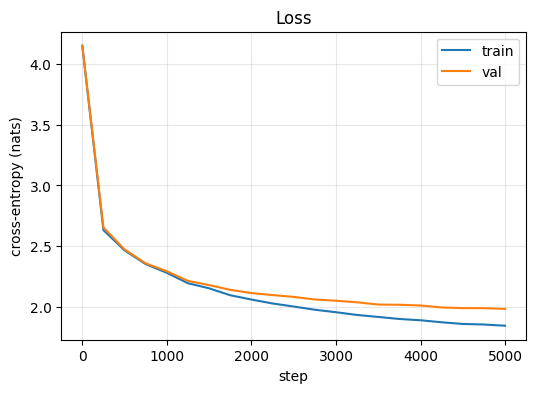

final: {'step': 4999, 'train': 1.8465337753295898, 'val': 1.984893798828125}



In he sournecedy, server LUchilendsice, appasment, go---

PERICHIO:
I hor paself Herld Kon beak, Gake untill her foll, Wet hener skings the
mare well hereir on of thand sigh:
Ther though do my lord, or sit threem:
You.
And put less this muckio, do been is on not kingsizer: gain's not oure in firsip:


In [3]:
steps = [h["step"] for h in history]
plt.figure(figsize=(6,4))
plt.plot(steps, [h["train"] for h in history], label="train")
plt.plot(steps, [h["val"] for h in history], label="val")
plt.xlabel("step"); plt.ylabel("cross-entropy (nats)"); plt.legend()
plt.title("Loss"); plt.grid(alpha=0.3); plt.show()
print("final:", history[-1])

# sample
out = generate(model, torch.zeros((1,1), dtype=torch.long), max_new_tokens=300, block_size=BLOCK)
print(ds.tokenizer.decode(out[0].tolist()))

**Takeaway.** Multi-head attention plus the feed-forward network reaches about **1.98 nats** — the largest single jump in the progression. Words start to look word-shaped. What is still missing is *depth*: stacking more of these blocks. Naively stacking them does not train well, which is the problem residual connections and LayerNorm exist to solve — the subject of the next notebook.